In [2]:
import pandas as pd
import numpy as np

# Task 0
Data extraction: get the data from 3 tables & combine it into single `.csv` file.
After that read this file using pandas to create Dataframe.
So it will be all joined data in 1 dataframe. Quick check - should be 74818 rows in it.

In [17]:
import sqlite3
import matplotlib.pyplot as plt

conn = sqlite3.connect('db.sqlite3')

sql_query = """
SELECT
    restaurant_order.id as order_id,
    restaurant_order.datetime as order_date,
    restaurant_orderitem.id as order_item_id,
    restaurant_orderitem.quantity,
    restaurant_orderitem.order_id as item_order_id,
    restaurant_product.id as product_id,
    restaurant_product.price as product_base_price,
    restaurant_product.name as product_name
FROM
    restaurant_order
JOIN
    restaurant_orderitem ON restaurant_order.id = restaurant_orderitem.order_id
JOIN
    restaurant_product ON restaurant_orderitem.product_id = restaurant_product.id
"""

df = pd.read_sql_query(sql_query, conn)

conn.close()

df.to_csv('restaurant_orders_complete.csv', index=False, encoding='utf-8')
print(f"Data saved at: 'restaurant_orders_complete.csv'")


Data saved at: 'restaurant_orders_complete.csv'


# Task 1
Get Top 10 most popular products in restaurant sold by Quantity.
Count how many times each product was sold and create a pie chart with percentage of popularity (by quantity) for top 10 of them.

Example:

![pie chart](../demo/pie.png)

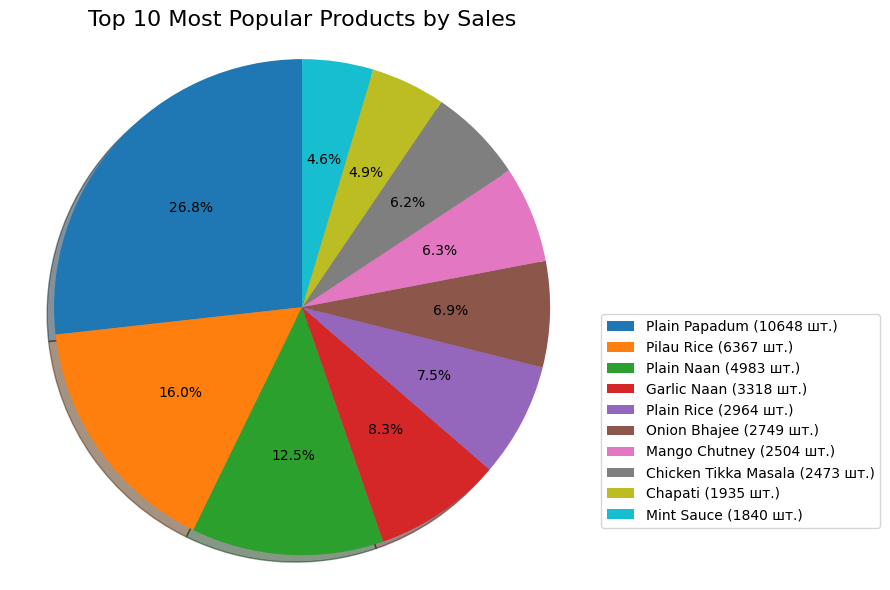

             product_name  quantity  percentage
188         Plain Papadum     10648        26.8
186            Pilau Rice      6367        16.0
187            Plain Naan      4983        12.5
81            Garlic Naan      3318         8.3
189            Plain Rice      2964         7.5
165          Onion Bhajee      2749         6.9
144         Mango Chutney      2504         6.3
52   Chicken Tikka Masala      2473         6.2
26                Chapati      1935         4.9
153            Mint Sauce      1840         4.6


In [29]:
df = pd.read_csv('restaurant_orders_complete.csv')
product_quantity = df.groupby('product_name')['quantity'].sum().reset_index()
top10_products = product_quantity.sort_values('quantity', ascending=False).head(10)
total_quantity = top10_products['quantity'].sum()
top10_products['percentage'] = (top10_products['quantity'] / total_quantity * 100).round(1)
plt.figure(figsize=(9, 6))
plt.pie(top10_products['quantity'], labels=None, autopct='%1.1f%%',
       startangle=90, shadow=True)
plt.axis('equal')
plt.title('Top 10 Most Popular Products by Sales', fontsize=16)

plt.legend(
    [f"{name} ({qty} шт.)" for name, qty in zip(top10_products['product_name'], top10_products['quantity'])],
    loc='best', bbox_to_anchor=(1, 0.5)
)
plt.tight_layout()
plt.show()

print(top10_products[['product_name', 'quantity', 'percentage']])


# Task 2
Calculate `Item Price` (Product Price * Quantity) for each Order Item in dataframe.
And Make the same Top 10 pie chart, but this time by `Item Price`. So this chart should describe not the most popular products by quantity, but which products (top 10) make the most money for restaurant. It should be also with percentage.

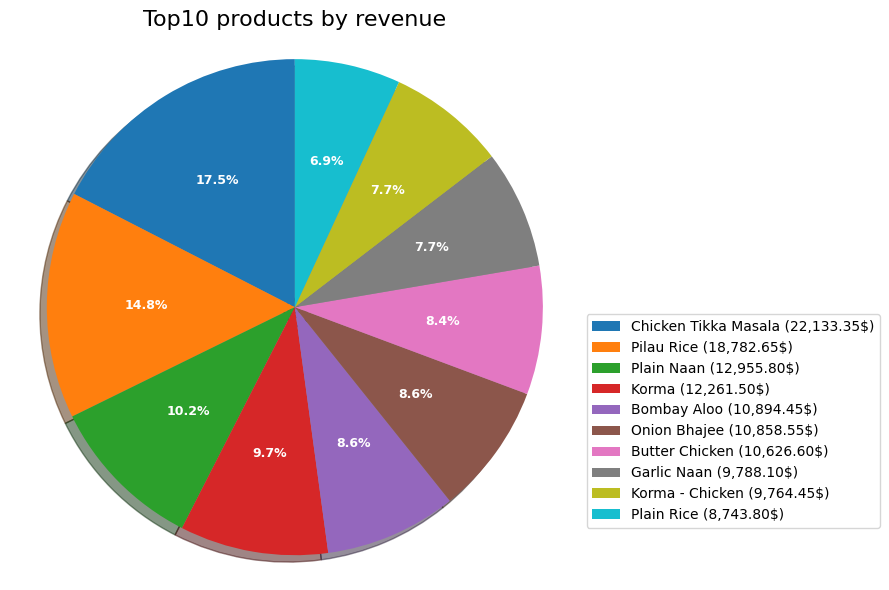

In [30]:
df = pd.read_csv('restaurant_orders_complete.csv')
df['item_total_price'] = df['product_base_price'] * df['quantity']
revenue_by_product = df.groupby('product_name')['item_total_price'].sum().reset_index()
revenue_by_product.columns = ['product_name', 'total_revenue']
top10_revenue = revenue_by_product.sort_values('total_revenue', ascending=False).head(10)
total_revenue = top10_revenue['total_revenue'].sum()
top10_revenue['percentage'] = (top10_revenue['total_revenue'] / total_revenue * 100).round(2)
top10_revenue.head(10).round(2)

plt.figure(figsize=(9, 6))
patches, texts, autotexts = plt.pie(top10_revenue['total_revenue'], autopct='%1.1f%%',
                                   startangle=90, shadow=True)
for autotext in autotexts:
    autotext.set_size(9)
    autotext.set_weight('bold')
    autotext.set_color('white')

plt.axis('equal')
plt.title('Top10 products by revenue', fontsize=16)

plt.legend(patches, [f"{name} ({rev:,.2f}$)" for name, rev in
                    zip(top10_revenue['product_name'], top10_revenue['total_revenue'])],
          loc='best', bbox_to_anchor=(1, 0.5))

plt.tight_layout()
plt.show()

# Task 3
Calculate `Order Hour` based on `Order Datetime`, which will tell about the specific our the order was created (from 0 to 23). Using `Order Hour` create a bar chart, which will tell the total restaurant income based on the hour order was created. So on x-axis - it will be values from 0 to 23 (hours), on y-axis - it will be the total sum of order prices, which were sold on that hour.

Example:

![bar chart](../demo/bar.png)

    order_hour  product_base_price
0            0              157.30
1            1               54.65
2            2              190.30
3            3                8.90
4            4               59.50
5            5               41.60
6            6               95.85
7            8              291.80
8            9              453.80
9           10              987.10
10          11             3050.30
11          12             8645.80
12          13             7247.85
13          14             2856.80
14          15             3207.70
15          16            12207.30
16          17            63865.00
17          18           117032.65
18          19            98099.10
19          20            45337.90
20          21            19663.15
21          22            10232.90
22          23              317.50


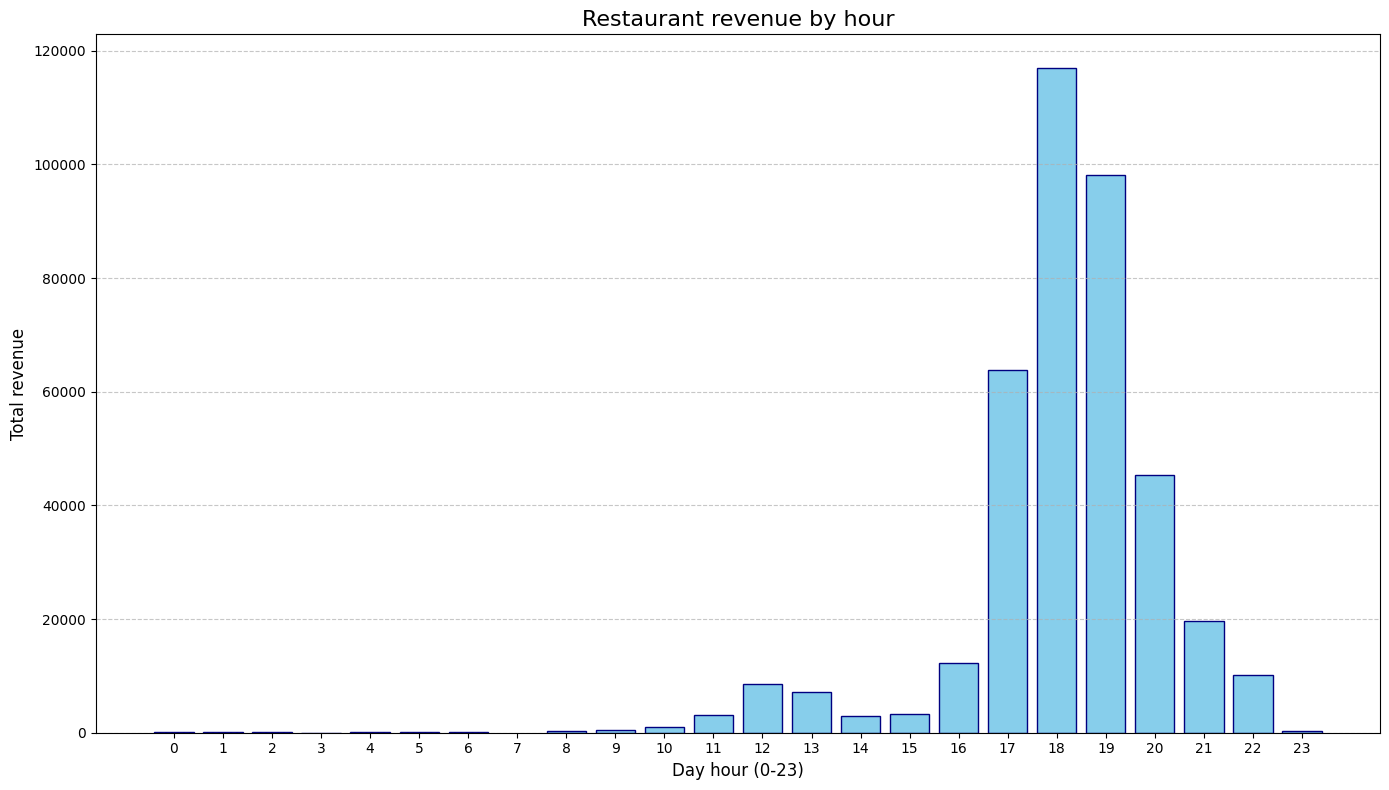

In [10]:
df = pd.read_csv('restaurant_orders_complete.csv')
df['order_date'] = pd.to_datetime(df['order_date'])
df['order_hour'] = df['order_date'].dt.hour
hourly_revenue = df.groupby('order_hour')['product_base_price'].sum().reset_index()
print(hourly_revenue)

plt.figure(figsize=(14, 8))
bars = plt.bar(hourly_revenue['order_hour'], hourly_revenue['product_base_price'],
        color='skyblue', edgecolor='navy')

plt.xlabel('Day hour (0-23)', fontsize=12)
plt.ylabel('Total revenue', fontsize=12)
plt.title('Restaurant revenue by hour', fontsize=16)
plt.xticks(range(0, 24))
plt.grid(axis='y', linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()


# Task 4
Make similar bar chart, but right now with `Order Day Of The Week` (from Monday to Sunday), and also analyze total restaurant income by each day of the week.

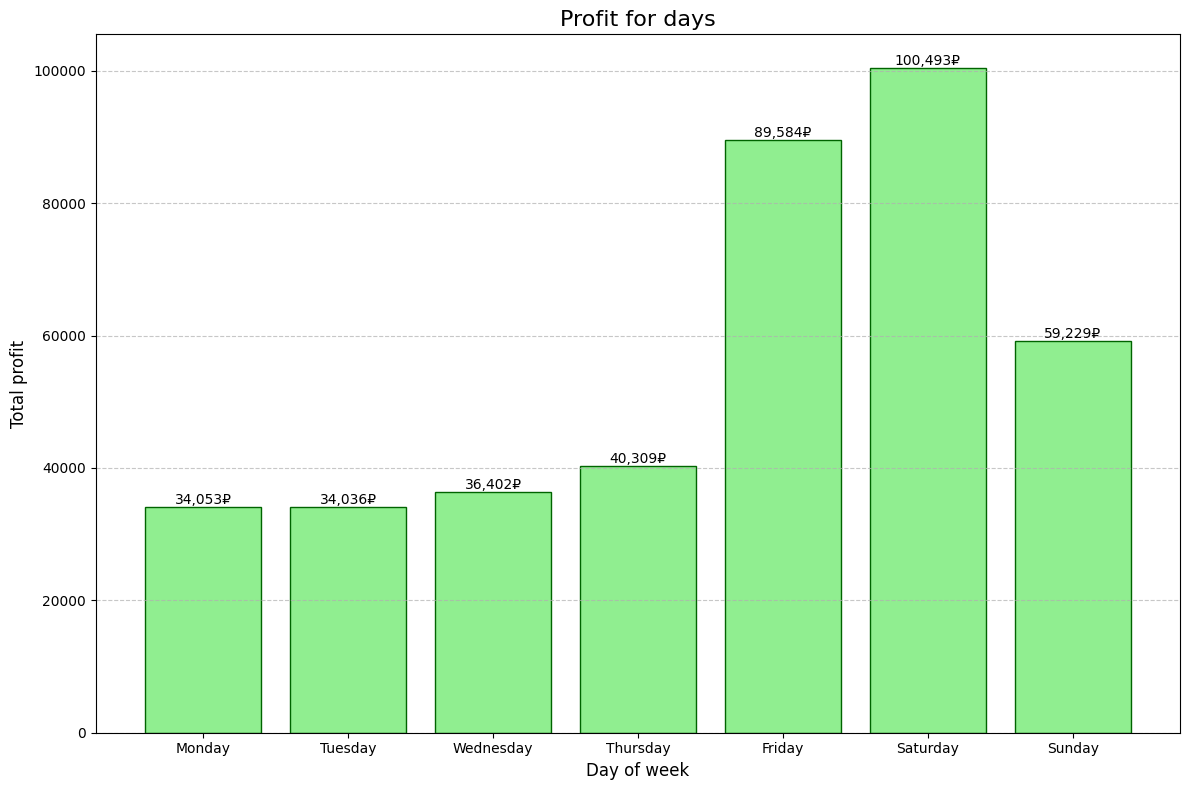

Daily restaurant profit:
    day_name  product_base_price  percentage
0     Monday            34052.60         8.6
1    Tuesday            34036.30         8.6
2  Wednesday            36401.90         9.2
3   Thursday            40308.60        10.2
4     Friday            89584.00        22.7
5   Saturday           100492.60        25.5
6     Sunday            59228.75        15.0

Days by revenue ranking:
    day_name  product_base_price  percentage
0   Saturday           100492.60        25.5
1     Friday            89584.00        22.7
2     Sunday            59228.75        15.0
3   Thursday            40308.60        10.2
4  Wednesday            36401.90         9.2
5     Monday            34052.60         8.6
6    Tuesday            34036.30         8.6

The most profitable day: Saturday (100,493₽)
Least profitable day: Tuesday (34,036₽)
Ratio of revenue between the most profitable and least profitable days: 2.95:1


In [7]:
df['order_date'] = pd.to_datetime(df['order_date'])
df['day_of_week'] = df['order_date'].dt.dayofweek
df['day_name'] = df['order_date'].dt.day_name()
daily_revenue = df.groupby(['day_of_week', 'day_name'])['product_base_price'].sum().reset_index()
daily_revenue = daily_revenue.sort_values('day_of_week')

plt.figure(figsize=(12, 8))
bars = plt.bar(daily_revenue['day_name'], daily_revenue['product_base_price'],
        color='lightgreen', edgecolor='darkgreen')

for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2., height,
            f'{height:,.0f}$',
            ha='center', va='bottom', rotation=0)

plt.xlabel('Day of week', fontsize=12)
plt.ylabel('Total profit', fontsize=12)
plt.title('Profit for days', fontsize=16)
plt.grid(axis='y', linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()

daily_revenue['percentage'] = (daily_revenue['product_base_price'] / daily_revenue['product_base_price'].sum() * 100).round(1)
daily_revenue['cumulative_percentage'] = daily_revenue['percentage'].cumsum()
top_days = daily_revenue.sort_values('product_base_price', ascending=False).reset_index(drop=True)
print("Daily restaurant profit:")
print(daily_revenue[['day_name', 'product_base_price', 'percentage']])
print("\nDays by revenue ranking:")
print(top_days[['day_name', 'product_base_price', 'percentage']])
print(f"\nThe most profitable day: {top_days.iloc[0]['day_name']} ({top_days.iloc[0]['product_base_price']:,.0f}$)")
print(f"Least profitable day: {top_days.iloc[-1]['day_name']} ({top_days.iloc[-1]['product_base_price']:,.0f}$)")
print(f"Ratio of revenue between the most profitable and least profitable days: {(top_days.iloc[0]['product_base_price'] / top_days.iloc[-1]['product_base_price']).round(2)}:1")
